In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

csv_files = glob.glob("*_assets.csv")

combined_df = \
(
    pd.
    concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
)

combined_df.to_csv('combined_data_RTH.csv', index=False)

In [2]:
csv_files

['2025-04-01_assets.csv',
 '2025-04-02_assets.csv',
 '2025-04-03_assets.csv',
 '2025-04-04_assets.csv',
 '2025-04-07_assets.csv',
 '2025-04-08_assets.csv',
 '2025-04-09_assets.csv',
 '2025-04-10_assets.csv']

In [3]:
combined_df.head(-5)

,Unnamed: 0,SPX,ES_BID,ES_ASK,VIX
0,2025-04-01 09:31:21.491248,5590.32,5631.75,5632.00,22.66
1,2025-04-01 09:31:24.535800,5590.70,5631.75,5632.00,22.66
2,2025-04-01 09:31:27.582698,5589.06,5629.50,5629.75,22.66
3,2025-04-01 09:31:30.632772,5588.66,5630.50,5630.75,22.66
4,2025-04-01 09:31:33.638817,5588.82,5629.75,5630.00,22.69
...,...,...,...,...,...
63146,2025-04-10 16:14:30.967265,5268.05,5313.00,5313.25,41.00
63147,2025-04-10 16:14:34.005253,5268.05,5314.00,5314.25,40.92
63148,2025-04-10 16:14:37.053558,5268.05,5315.00,5315.50,40.92
63149,2025-04-10 16:14:40.066367,5268.05,5315.50,5315.75,40.92


In [15]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63156 entries, 0 to 63155
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  63156 non-null  datetime64[ns]
 1   SPX         63156 non-null  float64       
 2   ES_BID      63156 non-null  float64       
 3   ES_ASK      63156 non-null  float64       
 4   VIX         63156 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 2.4 MB


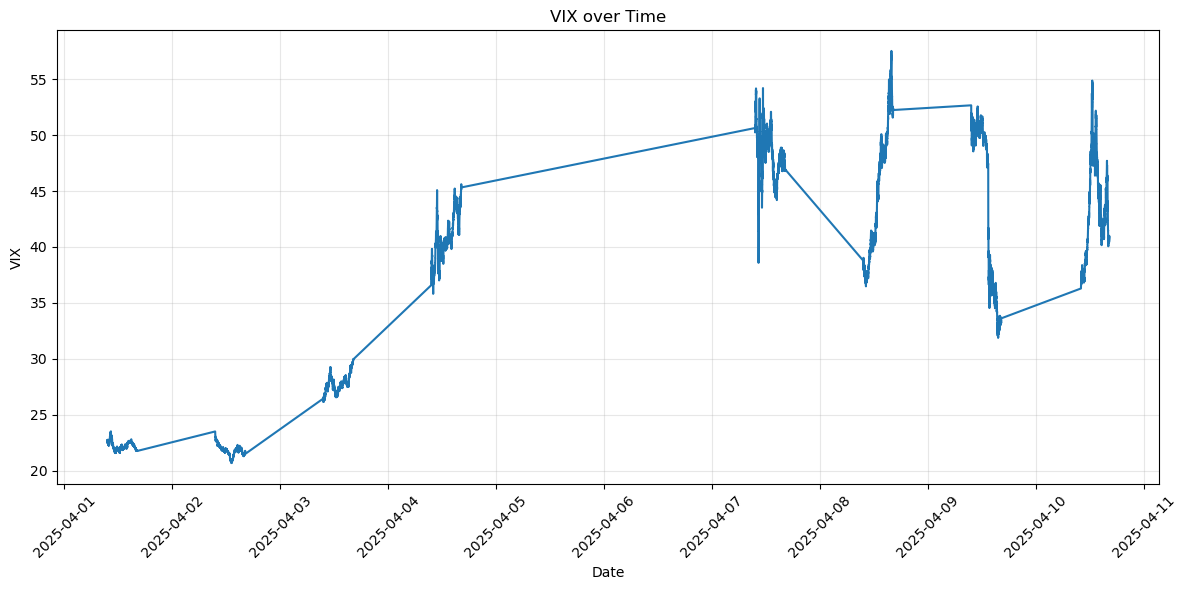

In [5]:
combined_df.iloc[:,0]=\
(
    pd
    .to_datetime(combined_df.iloc[:,0])
)
#Sort by date
combined_df = \
(
    combined_df
    .sort_values(by=combined_df.columns[0])
)

plt.figure(figsize=(12, 6))
plt.plot(combined_df.iloc[:, 0], combined_df['VIX'])
plt.xlabel('Date')
plt.ylabel('VIX')
plt.title('VIX over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
print(combined_df.iloc[:,0].head())

0    2025-04-01 09:31:21.491248
1    2025-04-01 09:31:24.535800
2    2025-04-01 09:31:27.582698
3    2025-04-01 09:31:30.632772
4    2025-04-01 09:31:33.638817
Name: Unnamed: 0, dtype: object


In [10]:
print(combined_df.iloc[:,0].dtype)

object


In [12]:
combined_df.iloc[:, 0] = pd.to_datetime(combined_df.iloc[:, 0], errors="coerce")
print(combined_df.iloc[:, 0].head())

0    2025-04-01 09:31:21.491248
1    2025-04-01 09:31:24.535800
2    2025-04-01 09:31:27.582698
3    2025-04-01 09:31:30.632772
4    2025-04-01 09:31:33.638817
Name: Unnamed: 0, dtype: object


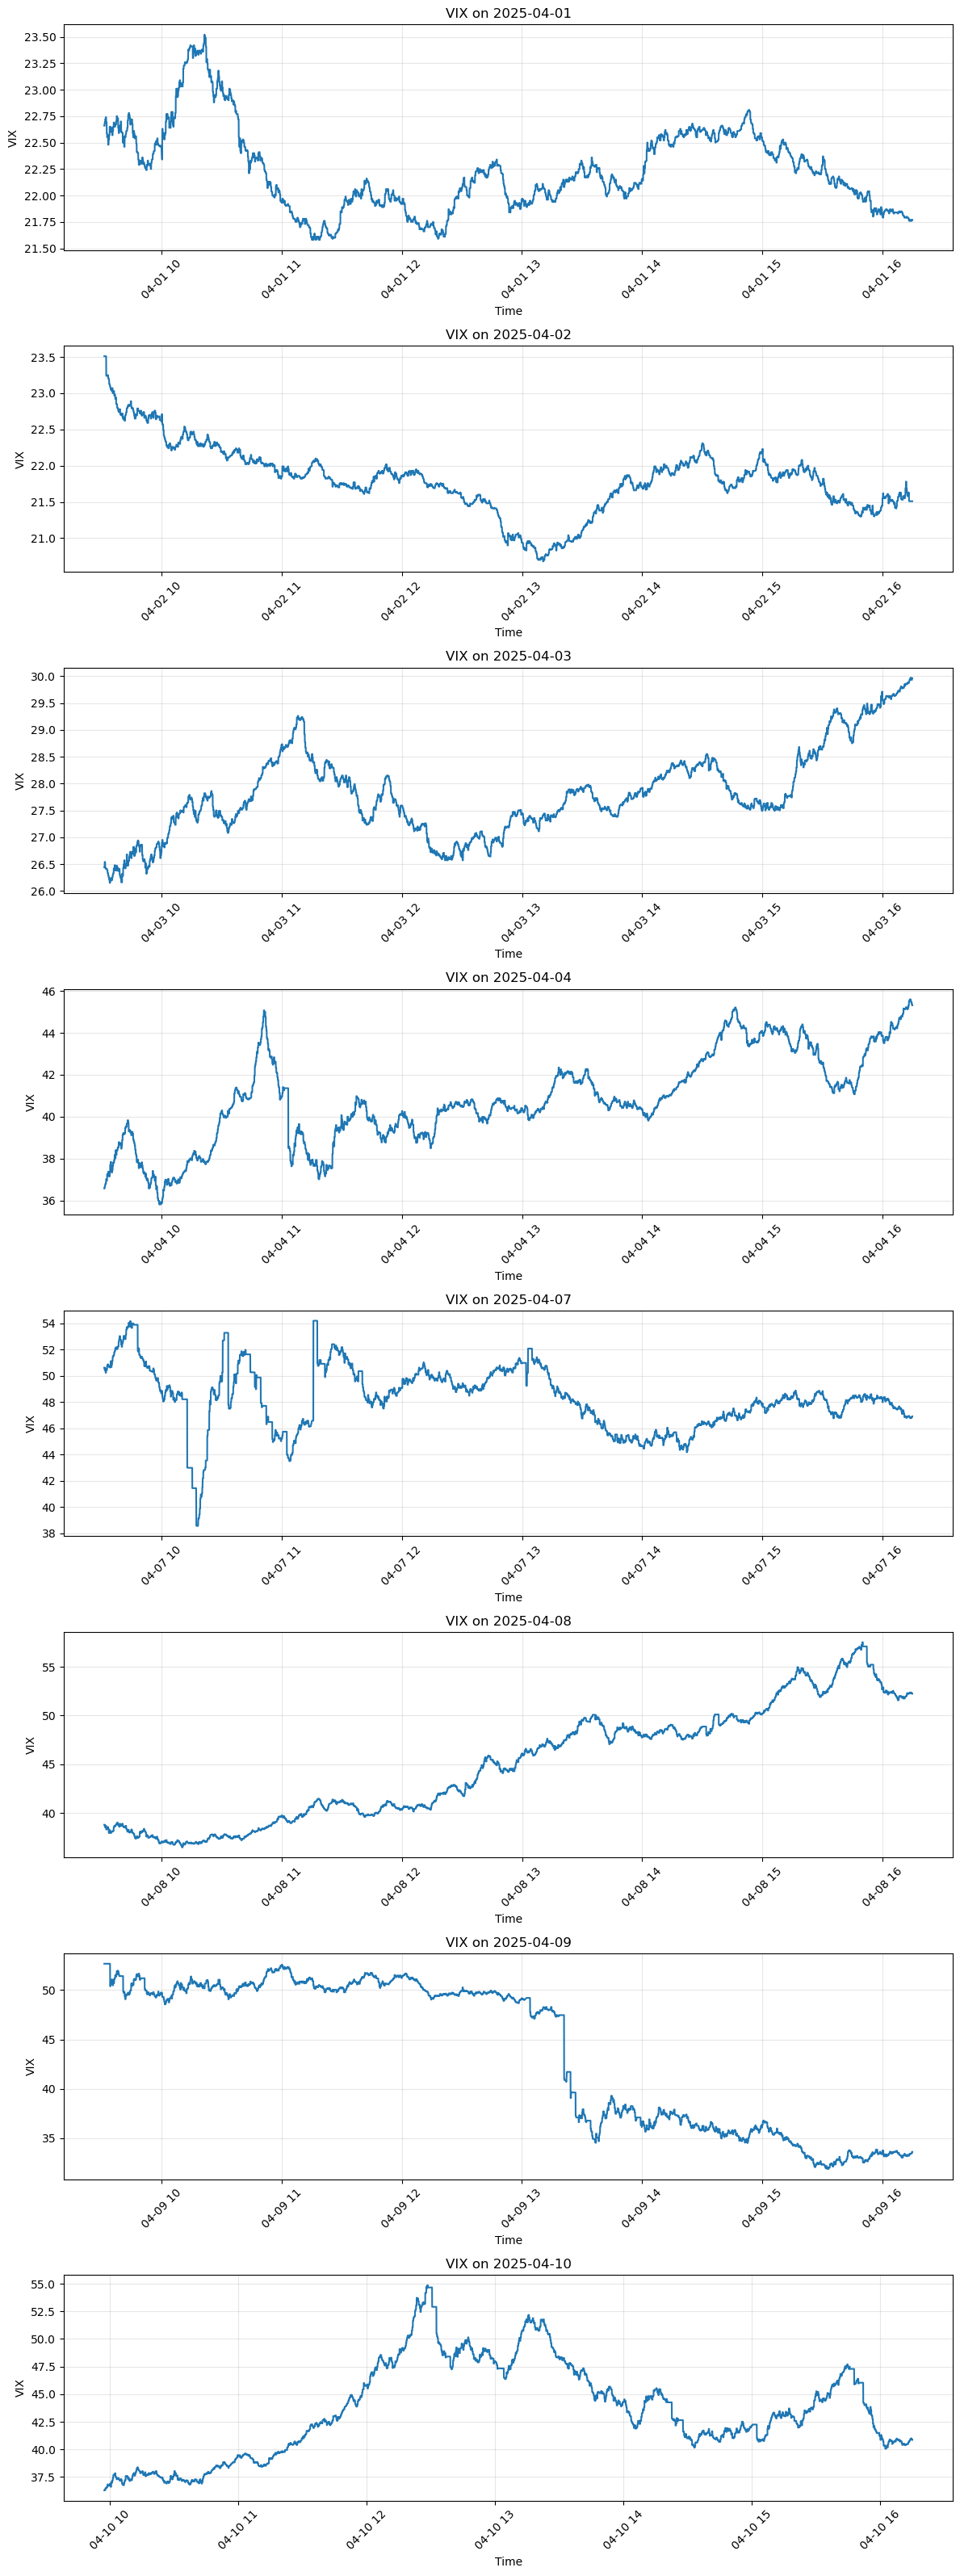

In [16]:
# Convert to datetime
first_col = combined_df.columns[0]
combined_df[first_col] = pd.to_datetime(combined_df[first_col], errors='coerce')

# Extract just the date (without time)
combined_df['date_only'] = combined_df.iloc[:, 0].dt.date

# Get unique dates
unique_dates = sorted(combined_df['date_only'].unique())

# Create subplots
n_dates = len(unique_dates)
fig, axes = plt.subplots(n_dates, 1, figsize=(12, 4*n_dates))

# Handle case where there's only one date
if n_dates == 1:
    axes = [axes]

for i, date in enumerate(unique_dates):
    date_data = combined_df[combined_df['date_only'] == date]
    axes[i].plot(date_data.iloc[:, 0], date_data['VIX'])
    axes[i].set_title(f'VIX on {date}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('VIX')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# Calculate mean and std dev for each day
daily_stats = combined_df.groupby('date_only')['VIX'].agg(['mean', 'std','max','min'])
daily_stats.columns = ['Mean_VIX', 'StdDev_VIX',"Max_Vix","Min_Vix"]

print(daily_stats)

             Mean_VIX  StdDev_VIX  Max_Vix  Min_Vix
date_only                                          
2025-04-01  22.240962    0.395850    23.52    21.58
2025-04-02  21.803949    0.467669    23.51    20.68
2025-04-03  27.815763    0.806226    29.97    26.15
2025-04-04  40.847001    2.155349    45.61    35.81
2025-04-07  48.315143    2.357192    54.20    38.58
2025-04-08  44.998267    5.828919    57.52    36.48
2025-04-09  43.828080    7.503791    52.66    31.90
2025-04-10  43.579287    4.313836    54.87    36.29


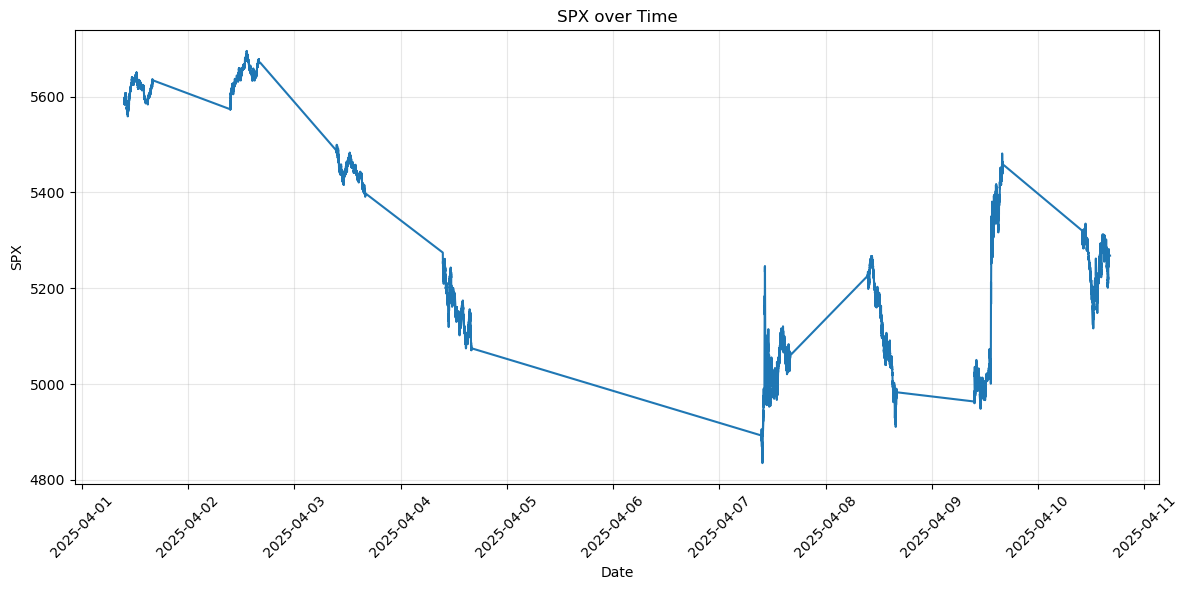

In [20]:
#Plotting SPX against Time
plt.figure(figsize=(12, 6))
plt.plot(combined_df.iloc[:, 0], combined_df['SPX'])
plt.xlabel('Date')
plt.ylabel('SPX')
plt.title('SPX over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
SPX_stats = \
(
    combined_df
    .groupby("date_only")["SPX"]
    .agg(["mean","std","max","min"])
)

SPX_stats.column=['Mean_SPX', 'StdDev_SPX',"Max_SPX","Min_SPX"]

print(SPX_stats)

                   mean         std      max      min
date_only                                            
2025-04-01  5612.375108   20.335850  5650.57  5558.60
2025-04-02  5650.034702   21.444592  5695.14  5572.38
2025-04-03  5442.939621   22.378204  5499.35  5390.83
2025-04-04  5154.146475   46.263418  5274.57  5070.47
2025-04-07  5030.184596   58.254504  5245.85  4835.16
2025-04-08  5115.206085   94.406036  5267.26  4910.68
2025-04-09  5166.501490  190.800275  5481.23  4948.43
2025-04-10  5251.028324   47.922972  5334.89  5116.23


C:\Users\chang\AppData\Local\Temp\ipykernel_5956\163405933.py:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  SPX_stats.column=['Mean_SPX', 'StdDev_SPX',"Max_SPX","Min_SPX"]
